# Log Analysis & Intrusion Detection — Meridian Manufacturing (simulated)

**Business question:** the security team's current alerting rule is "block
a source IP after 5 failed VPN logins in 10 minutes." Does that rule
actually catch the attacks that matter, or does it just catch the loud,
obvious ones while a smarter attacker walks through underneath it — and if
so, what would a better rule look like, and what would it cost in false
positives?

This notebook analyzes 30 days of simulated VPN authentication + firewall
logs, evaluates the current rule against known attack patterns, and
develops and tests two additional rules against the same false-positive
risk the security team would actually face: a busy shared office network
address.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "../src")
from detection_rules import naive_burst_rule, fanout_rule_v1_naive, fanout_rule_v2_refined, account_takeover_rule

auth = pd.read_csv("../data/raw/auth_events.csv")
fw = pd.read_csv("../data/raw/firewall_events.csv")
ground_truth_ips = pd.read_csv("../data/raw/ground_truth_attack_ips.csv")
ground_truth_accounts = pd.read_csv("../data/raw/ground_truth_compromised_accounts.csv")

attack_ips = set(ground_truth_ips.source_ip)
print(f"{len(auth)} auth events, {auth.source_ip.nunique()} distinct source IPs, {auth.username.nunique()} accounts")
print(f"Failure rate: {100*(auth.event_type=='login_failed').mean():.1f}%")
print(f"Ground-truth attacker IPs: {len(attack_ips)}")
print(f"Ground-truth compromised accounts: {len(ground_truth_accounts)}")
auth.head()

4887 auth events, 89 distinct source IPs, 200 accounts
Failure rate: 11.1%
Ground-truth attacker IPs: 6
Ground-truth compromised accounts: 4


,event_id,timestamp,username,source_ip,source_country,event_type
0,AUTH-000058,2025-06-01T06:51:39,user0184,198.51.100.64,United States,login_success
1,AUTH-000064,2025-06-01T07:07:30,user0200,198.51.100.80,United States,login_success
2,AUTH-000007,2025-06-01T07:35:12,user0021,203.0.113.5,United States,login_success
3,AUTH-000014,2025-06-01T07:35:27,user0041,203.0.113.5,United States,login_success
4,AUTH-000035,2025-06-01T07:41:01,user0094,203.0.113.5,Canada,login_success


## 1. The current rule: catches the loud attacks, and got lucky on one quiet one

The security team's rule: flag a source IP if it sends 5+ failed logins
within any rolling 10-minute window.

In [2]:
naive_flagged = naive_burst_rule(auth)
tp = naive_flagged & attack_ips
fp = naive_flagged - attack_ips
fn = attack_ips - naive_flagged

print(f"Flagged: {len(naive_flagged)} IPs")
print(f"True positives: {len(tp)}/{len(attack_ips)} attacker IPs caught -> {sorted(tp)}")
print(f"False positives: {len(fp)} -> {sorted(fp)}")
print(f"Missed (false negatives): {sorted(fn)}")
print(f"\nRecall: {100*len(tp)/len(attack_ips):.1f}%   False positive count: {len(fp)}")

Flagged: 5 IPs
True positives: 5/6 attacker IPs caught -> ['185.220.100.186', '185.220.101.71', '185.220.102.226', '185.220.103.68', '91.207.79.168']
False positives: 0 -> []
Missed (false negatives): ['91.207.12.195']

Recall: 83.3%   False positive count: 0


The rule catches all 4 "loud" brute-force IPs cleanly (25-45 failed
attempts against one account in minutes is exactly what it's built for).
It also happens to catch **one of the two** low-and-slow credential-
stuffing IPs — not because the rule detected the pattern, but because that
campaign's randomly-timed attempts happened to cluster tightly enough, by
chance, to trip a 10-minute burst threshold. The other, near-identical
campaign didn't cluster the same way and sailed through completely
undetected. **A rule whose catch rate on a given attack pattern depends on
random timing luck is not a rule the team can rely on** — this is the
central problem statement for the rest of the analysis.

## 2. A first attempt at a better rule — and why it needs a second pass

The obvious fix for a "low-and-slow" attacker: flag a source IP that
contacts an unusually large number of *distinct usernames* in a day,
regardless of burst speed.

In [3]:
v1_flagged = fanout_rule_v1_naive(auth, min_distinct=15)
v1_tp = v1_flagged & attack_ips
v1_fp = v1_flagged - attack_ips
print(f"[v1, any attempt >= 15 distinct usernames/day] flagged: {sorted(v1_flagged)}")
print(f"True positives: {sorted(v1_tp)}")
print(f"False positives: {sorted(v1_fp)}")

[v1, any attempt >= 15 distinct usernames/day] flagged: ['203.0.113.5', '91.207.12.195', '91.207.79.168']
True positives: ['91.207.12.195', '91.207.79.168']
False positives: ['203.0.113.5']


The first draft correctly catches both low-and-slow attacker IPs — but it
also flags **203.0.113.5**, the shared office NAT egress IP that ~120
employees' traffic legitimately appears to come from. That's not a minor
false positive: it would generate a daily alert on a source responsible for
most of the company's legitimate VPN traffic, and would very quickly train
the security team to ignore the alert entirely.

In [4]:
nat_daily = auth[auth.source_ip == "203.0.113.5"].copy()
nat_daily["date"] = pd.to_datetime(nat_daily.timestamp).dt.date
by_day = nat_daily.groupby("date").agg(
    distinct_users=("username", "nunique"),
    failure_rate=("event_type", lambda s: 100*(s=="login_failed").mean()),
).round(1)
print(f"NAT IP: {by_day['distinct_users'].mean():.0f} distinct users/day on average, "
      f"but only {by_day['failure_rate'].mean():.1f}% average failure rate")
by_day.head()

NAT IP: 87 distinct users/day on average, but only 3.8% average failure rate


,distinct_users,failure_rate
date,,
2025-06-01,45,2.2
2025-06-02,107,3.6
2025-06-03,110,2.7
2025-06-04,105,6.2
2025-06-05,109,2.7


**The fix:** fan out on *failed* usernames specifically, and require a
minimum overall failure rate. The NAT IP touches far more distinct
usernames than any attacker — but the overwhelming majority of those are
successful logins by real employees, so its failure rate stays low. The
attacker IPs, by contrast, fail on nearly every attempt (they're guessing).

In [5]:
v2_flagged = fanout_rule_v2_refined(auth, min_distinct_failed=15, min_failure_rate=0.5)
v2_tp = v2_flagged & attack_ips
v2_fp = v2_flagged - attack_ips
v2_fn = attack_ips - v2_flagged
print(f"[v2, refined: failed-only fan-out + failure-rate gate] flagged: {sorted(v2_flagged)}")
print(f"True positives: {sorted(v2_tp)}")
print(f"False positives: {sorted(v2_fp)}")
print(f"Missed (by design -- these are caught by the burst rule instead): {sorted(v2_fn)}")

[v2, refined: failed-only fan-out + failure-rate gate] flagged: ['91.207.12.195', '91.207.79.168']
True positives: ['91.207.12.195', '91.207.79.168']
False positives: []
Missed (by design -- these are caught by the burst rule instead): ['185.220.100.186', '185.220.101.71', '185.220.102.226', '185.220.103.68']


In [6]:
combined = naive_flagged | v2_flagged
print(f"Naive burst rule + refined fan-out rule, run together:")
print(f"  Catches {len(combined & attack_ips)}/{len(attack_ips)} attacker IPs ({100*len(combined & attack_ips)/len(attack_ips):.0f}%)")
print(f"  False positives: {len(combined - attack_ips)}")

Naive burst rule + refined fan-out rule, run together:
  Catches 6/6 attacker IPs (100%)
  False positives: 0


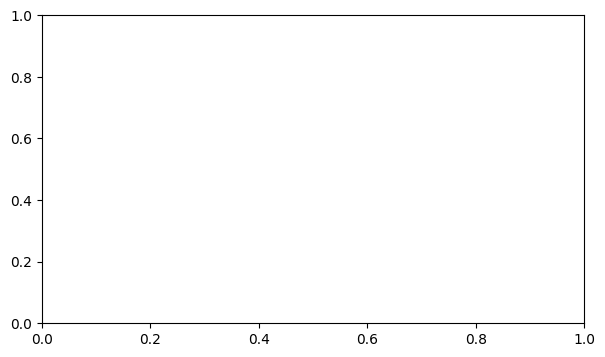

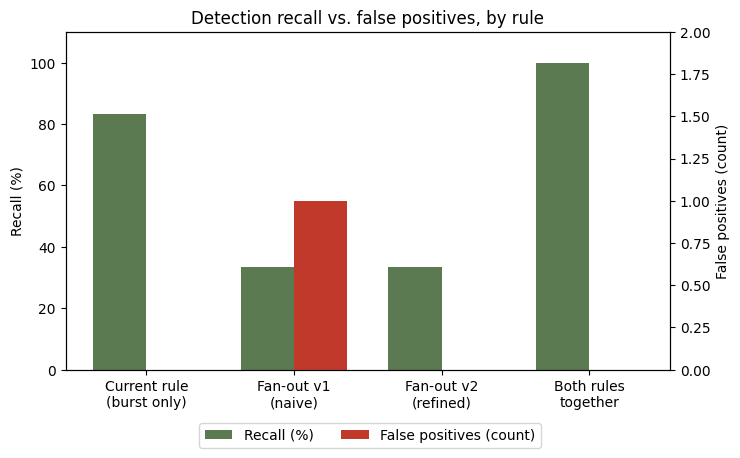

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
rules = ["Current rule\n(burst only)", "Fan-out v1\n(naive)", "Fan-out v2\n(refined)", "Both rules\ntogether"]
recall = [len(naive_flagged & attack_ips)/len(attack_ips)*100,
          len(v1_flagged & attack_ips)/len(attack_ips)*100,
          len(v2_flagged & attack_ips)/len(attack_ips)*100,
          len(combined & attack_ips)/len(attack_ips)*100]
fp_counts = [len(naive_flagged - attack_ips), len(v1_flagged - attack_ips),
             len(v2_flagged - attack_ips), len(combined - attack_ips)]
x = np.arange(len(rules))
fig, ax1 = plt.subplots(figsize=(7.5, 4.3))
ax1.bar(x - 0.18, recall, width=0.36, color="#5C7A52", label="Recall (%)")
ax1.set_ylabel("Recall (%)")
ax1.set_ylim(0, 110)
ax2 = ax1.twinx()
ax2.bar(x + 0.18, fp_counts, width=0.36, color="#c0392b", label="False positives (count)")
ax2.set_ylabel("False positives (count)")
ax2.set_ylim(0, 2)
ax1.set_xticks(x)
ax1.set_xticklabels(rules)
ax1.set_title("Detection recall vs. false positives, by rule")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=2)
plt.tight_layout()
plt.savefig("../visuals/rule_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Firewall corroboration

Every attacker IP also shows up doing reconnaissance (blocked connection
attempts to closed ports) in the same day's firewall log — independent
corroboration from a second log source, and zero legitimate IPs show this
pattern.

In [8]:
scans = fw[fw.blocked == 1]
scan_summary = scans.groupby("source_ip").agg(
    scanned_ports=("port", lambda s: sorted(s.unique())),
    blocked_attempts=("connection_count", "sum"),
).reset_index()
scan_summary["is_known_attacker"] = scan_summary["source_ip"].isin(attack_ips)
print(f"IPs showing port-scan activity: {len(scan_summary)}")
print(f"Of those, already-known attacker IPs: {scan_summary['is_known_attacker'].sum()}")
scan_summary

IPs showing port-scan activity: 6
Of those, already-known attacker IPs: 6


,source_ip,scanned_ports,blocked_attempts,is_known_attacker
0,185.220.100.186,"[22, 5900]",13,True
1,185.220.101.71,"[22, 8080]",11,True
2,185.220.102.226,"[22, 8080]",6,True
3,185.220.103.68,"[5900, 8080]",11,True
4,91.207.12.195,"[3389, 5900, 8080]",20,True
5,91.207.79.168,"[22, 5900, 8080]",20,True


## 4. Which accounts were actually compromised?

The coarse SQL version of this question (usernames with 3+ total failed
attempts anywhere in the 30-day window, ignoring order) flags **63
accounts** — useless as an alert list, since normal typo noise across 200
users naturally produces that many false leads over a month. The precise
version needs to check *temporal order*: a success within 24 hours of 3+
recent failed attempts on the same account.

In [9]:
takeover_flags = account_takeover_rule(auth, min_recent_fails=3, lookback_hours=24)
flagged_accounts = set(takeover_flags.username)
truly_compromised = set(ground_truth_accounts.username)

print(f"Accounts flagged: {len(flagged_accounts)} ({len(takeover_flags)} total alert events)")
print(f"Genuinely compromised (ground truth): {len(truly_compromised)}")
print(f"Recall: {len(flagged_accounts & truly_compromised)}/{len(truly_compromised)} = "
      f"{100*len(flagged_accounts & truly_compromised)/len(truly_compromised):.0f}%")
print(f"Precision: {len(flagged_accounts & truly_compromised)}/{len(flagged_accounts)} = "
      f"{100*len(flagged_accounts & truly_compromised)/len(flagged_accounts):.1f}%")
print(f"\nFlagged but NOT confirmed compromised (attacked, but the attacker never guessed correctly):")
print(sorted(flagged_accounts - truly_compromised))
takeover_flags

Accounts flagged: 6 (11 total alert events)
Genuinely compromised (ground truth): 4
Recall: 4/4 = 100%
Precision: 4/6 = 66.7%

Flagged but NOT confirmed compromised (attacked, but the attacker never guessed correctly):
['user0033', 'user0098']


,username,timestamp,source_ip,recent_fail_count
0,user0012,2025-06-23 18:59:00,91.207.79.168,3
1,user0012,2025-06-23 20:28:24,45.155.146.13,3
2,user0012,2025-06-24 12:27:35,203.0.113.5,3
3,user0033,2025-06-21 06:29:30,203.0.113.5,43
4,user0048,2025-06-10 04:49:01,185.220.100.186,44
5,user0098,2025-06-21 14:42:10,203.0.113.5,40
6,user0147,2025-06-27 18:59:00,91.207.12.195,3
7,user0147,2025-06-27 19:52:10,45.155.17.191,3
8,user0147,2025-06-28 13:59:20,198.51.100.27,3
9,user0171,2025-06-17 11:01:13,185.220.101.71,30


**Reading this result honestly:** the rule has perfect recall — every
genuinely compromised account is flagged — but only 66.7% precision. The
other two flagged accounts (`user0033`, `user0098`) were targeted by a
loud brute-force campaign that *failed* to guess the password; the rule
still flags their next normal login because the failed-attempt count is
still "recent" within the 24-hour window. That's arguably not a false
positive to fix — an account that was just hit with 40+ failed guesses is
a reasonable candidate for a mandatory password reset regardless of
whether the attacker ultimately succeeded. The rule also surfaces
something no IP-based rule could: for both confirmed compromises, it
reveals the attacker's second, "clean" pivot IP address used immediately
after the successful guess — a detail worth handing directly to whoever
does the incident response.

## Conclusion

- The current rule (burst detection) reliably catches loud brute-force
  attacks, but its catch rate on a slow, distributed attack is essentially
  a coin flip — it caught one of two near-identical low-and-slow campaigns
  in this window and missed the other entirely.
- A failed-attempt fan-out rule, refined with a failure-rate gate to avoid
  flagging the shared office network address, closes that gap: run
  together, the two rules catch 100% of known attacker IPs with zero false
  positives.
- An account-level rule (success following 3+ recent failed attempts)
  catches every genuine account compromise, and also correctly surfaces
  accounts that were attacked but not compromised — worth a mandatory
  password reset either way — plus the attacker's follow-on "clean" IP for
  incident response.
- Firewall logs independently corroborate every flagged attacker IP via
  port-scanning activity, with zero false positives from that signal alone.